In [2]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from scipy import stats

warnings.filterwarnings('ignore')

In [3]:
# ============================================
# 1. SETUP AND SEEDS
# ============================================

# Set global random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [4]:
# ============================================
# 2. DATA LOADING AND PREPARATION
# ============================================

# Load data
df = pd.read_csv('SU.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Select closing price series
ts = df['SU_Close'].ffill()

# Split into train/test
test_size = 30
train_ts = ts[:-test_size]
test_ts = ts[-test_size:]

print("Training set:", len(train_ts), "days")
print("Test set:", len(test_ts), "days")

Training set: 4519 days
Test set: 30 days


In [5]:
# ============================================
# 3. ARIMA COMPONENT - USER INPUT PARAMETERS
# ============================================

print("\n" + "="*60)
print("ARIMA COMPONENT - USER INPUT PARAMETERS")
print("="*60)

# Ask user for ARIMA parameters
print("\nPlease enter the ARIMA parameters from your previous ARIMA run:")
print("(These should be the values you got from your ARIMA-only code)")

# Get user input with validation
while True:
    try:
        p = int(input("Enter AR parameter p: "))
        if p < 0:
            print("p must be >= 0. Please try again.")
            continue
        break
    except ValueError:
        print("Please enter a valid integer for p.")

while True:
    try:
        d = int(input("Enter differencing parameter d: "))
        if d < 0:
            print("d must be >= 0. Please try again.")
            continue
        break
    except ValueError:
        print("Please enter a valid integer for d.")

while True:
    try:
        q = int(input("Enter MA parameter q: "))
        if q < 0:
            print("q must be >= 0. Please try again.")
            continue
        break
    except ValueError:
        print("Please enter a valid integer for q.")

print(f"\nUsing ARIMA({p}, {d}, {q}) as provided by user")
print(f"Note: No grid search will be performed for ARIMA parameters.")


ARIMA COMPONENT - USER INPUT PARAMETERS

Please enter the ARIMA parameters from your previous ARIMA run:
(These should be the values you got from your ARIMA-only code)

Using ARIMA(2, 1, 4) as provided by user
Note: No grid search will be performed for ARIMA parameters.


In [6]:
# ============================================
# 4. FIT ARIMA WITH USER PARAMETERS
# ============================================

print("\n" + "="*60)
print("FITTING ARIMA WITH USER-PROVIDED PARAMETERS")
print("="*60)

try:
    # Fit ARIMA on training data with user-provided parameters
    arima_model = ARIMA(train_ts, order=(p, d, q))
    arima_fit = arima_model.fit()
    
    # Get ARIMA predictions and residuals
    arima_train_pred = arima_fit.fittedvalues
    arima_residuals = train_ts - arima_train_pred
    arima_residuals.iloc[0] = 0
    arima_residuals = arima_residuals.dropna()
    
    print(f"\nARIMA({p},{d},{q}) successfully fitted to training data")
    print(f"AIC: {arima_fit.aic:.2f}")
    print(f"BIC: {arima_fit.bic:.2f}")
    print(f"Log Likelihood: {arima_fit.llf:.2f}")
    
    # Display ARIMA coefficients if available
    if len(arima_fit.params) > 0:
        print("\nInitial ARIMA Model Coefficients:")
        param_names = arima_fit.param_names
        param_values = arima_fit.params
        param_stderrs = arima_fit.bse
        param_pvalues = arima_fit.pvalues
        
        print(f"{'Parameter':<15} {'Coefficient':<15} {'Std Error':<15} {'z':<15} {'P>|z|':<15}")
        print("-" * 75)
        
        for name, value, stderr, pval in zip(param_names, param_values, param_stderrs, param_pvalues):
            # Calculate z-statistic
            z_stat = value / stderr if stderr != 0 else 0
            print(f"{name:<15} {value:<15.6f} {stderr:<15.6f} {z_stat:<15.6f} {pval:<15.6f}")
    
    print(f"\nARIMA residuals calculated")
    print(f"ARIMA residuals stats - Mean: {arima_residuals.mean():.4f}, Std: {arima_residuals.std():.4f}")
    
except Exception as e:
    print(f"\nError fitting ARIMA({p},{d},{q}): {str(e)}")
    print("\nPlease check your parameters and try again.")
    print("Common issues:")
    print("  1. p or q too high for the available data")
    print("  2. Non-stationary series (d may need adjustment)")
    print("  3. Invalid parameter combination")
    exit(1)


FITTING ARIMA WITH USER-PROVIDED PARAMETERS

ARIMA(2,1,4) successfully fitted to training data
AIC: 18647.05
BIC: 18691.96
Log Likelihood: -9316.52

Initial ARIMA Model Coefficients:
Parameter       Coefficient     Std Error       z               P>|z|          
---------------------------------------------------------------------------
ar.L1           0.495461        0.008827        56.130102       0.000000       
ar.L2           -0.960524       0.007989        -120.235154     0.000000       
ma.L1           -0.527444       0.010646        -49.545071      0.000000       
ma.L2           0.898509        0.012675        70.886110       0.000000       
ma.L3           -0.019670       0.007883        -2.495284       0.012586       
ma.L4           -0.062819       0.008295        -7.573538       0.000000       
sigma2          3.619274        0.025837        140.081792      0.000000       

ARIMA residuals calculated
ARIMA residuals stats - Mean: 0.0422, Std: 1.9020


In [7]:
# ============================================
# 5. LSTM COMPONENT FOR RESIDUALS
# ============================================

class ResidualLSTMModel(nn.Module):
    """LSTM model for predicting ARIMA residuals"""
    def __init__(self, input_size, hidden_layer_size, output_size_fixed, dropout_rate):
        super(ResidualLSTMModel, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_layer_size, output_size_fixed)
        
    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), self.hidden_layer_size).to(x.device)
        c0 = torch.zeros(1, x.size(0), self.hidden_layer_size).to(x.device)
        lstm_out, _ = self.lstm(x, (h0, c0))
        last_output = lstm_out[:, -1, :]
        dropout_out = self.dropout(last_output)
        output = self.fc(dropout_out)
        return output

# Initialize scaler for residuals
residual_scaler = MinMaxScaler(feature_range=(0, 1))
residual_scaler.fit(arima_residuals.values.reshape(-1, 1))

def prepare_residual_sequences(residual_series, seq_length, forecast_horizon=5):
    if isinstance(residual_series, pd.DataFrame):
        values = residual_series.values.flatten()
    elif isinstance(residual_series, pd.Series):
        values = residual_series.values
    else:
        values = residual_series
    
    scaled_data = residual_scaler.transform(values.reshape(-1, 1)).flatten()
    
    X_list, y_list = [], []
    data_length = len(scaled_data)
    
    if data_length >= seq_length + forecast_horizon:
        for i in range(data_length - seq_length - forecast_horizon + 1):
            X_list.append(scaled_data[i:(i + seq_length)])
            y_list.append(scaled_data[(i + seq_length):(i + seq_length + forecast_horizon)])
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    if X.shape[0] > 0:
        X = X.reshape(X.shape[0], X.shape[1], 1)
    else:
        X = np.empty((0, seq_length, 1))
    
    if y.shape[0] == 0:
        y = np.empty((0, forecast_horizon))
    
    return X, y

class ResidualDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def train_residual_lstm(model, train_loader, val_loader, optimizer, criterion, 
                       epochs, device, patience, model_path):
    best_val_rmse = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        val_losses = []
        
        with torch.no_grad():
            for X_batch_val, y_batch_val in val_loader:
                X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)
                outputs_val = model(X_batch_val)
                val_loss = criterion(outputs_val, y_batch_val)
                val_losses.append(val_loss.item())
        
        avg_val_loss = np.mean(val_losses)
        avg_val_rmse = np.sqrt(avg_val_loss)
        
        if avg_val_rmse < best_val_rmse:
            best_val_rmse = avg_val_rmse
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve == patience:
                break
    
    model.load_state_dict(torch.load(model_path))
    return best_val_rmse

In [8]:
# ============================================
# 6. HYPERPARAMETER TUNING FOR RESIDUAL LSTM (70/30 HOLD-OUT)
# ============================================

print("\n" + "="*60)
print("HYPERPARAMETER TUNING FOR RESIDUAL LSTM (70/30 HOLD-OUT)")
print("="*60)

# Define hyperparameter grid (same as original LSTM grid)
hyperparameter_grid = {
    'lstm_units': [32, 64],
    'dropout_rate': [0.2, 0.5],
    'seq_length': [22, 66, 132]
}

print(f"Hyperparameter grid to test:")
print(f"  LSTM Units: {hyperparameter_grid['lstm_units']}")
print(f"  Dropout Rate: {hyperparameter_grid['dropout_rate']}")
print(f"  Sequence Length: {hyperparameter_grid['seq_length']}")
print(f"Total combinations: {len(hyperparameter_grid['lstm_units']) * len(hyperparameter_grid['dropout_rate']) * len(hyperparameter_grid['seq_length'])}")

# Split residuals into train (70%) and validation (30%) sets
val_ratio = 0.3
split_idx = int(len(arima_residuals) * (1 - val_ratio))

train_residuals = arima_residuals.iloc[:split_idx]
val_residuals = arima_residuals.iloc[split_idx:]

print(f"\nResiduals split:")
print(f"  Training residuals: {len(train_residuals)} points ({100*(1-val_ratio):.0f}%)")
print(f"  Validation residuals: {len(val_residuals)} points ({100*val_ratio:.0f}%)")
print(f"  Training date range: {train_residuals.index[0].date()} to {train_residuals.index[-1].date()}")
print(f"  Validation date range: {val_residuals.index[0].date()} to {val_residuals.index[-1].date()}")

# Store results
all_results = []
best_val_rmse = float('inf')
best_hyperparams = None

print("\nStarting hyperparameter tuning...")

for lstm_units in hyperparameter_grid['lstm_units']:
    for dropout_rate in hyperparameter_grid['dropout_rate']:
        for seq_length in hyperparameter_grid['seq_length']:
            
            print(f"\nTesting: LSTM Units={lstm_units}, Dropout={dropout_rate}, Seq Length={seq_length}")
            
            # Prepare sequences for this seq_length
            X_train_res, y_train_res = prepare_residual_sequences(train_residuals, seq_length)
            X_val_res, y_val_res = prepare_residual_sequences(val_residuals, seq_length)
            
            # Check if we have enough data for sequences
            if len(X_train_res) == 0 or len(X_val_res) == 0:
                print(f"  Skipped: Not enough data for sequences (train={len(X_train_res)}, val={len(X_val_res)})")
                continue
            
            # Create DataLoaders
            train_dataset = ResidualDataset(X_train_res, y_train_res)
            val_dataset = ResidualDataset(X_val_res, y_val_res)
            
            train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
            val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
            
            # Initialize model
            model = ResidualLSTMModel(
                input_size=1,
                hidden_layer_size=lstm_units,
                output_size_fixed=5,
                dropout_rate=dropout_rate
            ).to(device)
            
            optimizer = optim.Adam(model.parameters(), lr=0.01)
            criterion = nn.MSELoss()
            
            # Train and evaluate (with fewer epochs for speed)
            model_path = f'temp_residual_model_{lstm_units}_{dropout_rate}_{seq_length}.pth'
            val_rmse = train_residual_lstm(
                model, train_loader, val_loader, optimizer, criterion,
                epochs=100, device=device, patience=20, model_path=model_path
            )
            
            print(f"  Validation RMSE: {val_rmse:.6f}")
            
            # Store results
            all_results.append({
                'lstm_units': lstm_units,
                'dropout_rate': dropout_rate,
                'seq_length': seq_length,
                'val_rmse': val_rmse,
                'train_samples': len(X_train_res),
                'val_samples': len(X_val_res)
            })
            
            # Update best hyperparameters
            if val_rmse < best_val_rmse:
                best_val_rmse = val_rmse
                best_hyperparams = {
                    'lstm_units': lstm_units,
                    'dropout_rate': dropout_rate,
                    'seq_length': seq_length
                }

# Display results
print("\n" + "="*60)
print("HYPERPARAMETER TUNING RESULTS")
print("="*60)

if len(all_results) == 0:
    print("No valid hyperparameter combinations found. Using defaults.")
    lstm_units = 64
    dropout_rate = 0.2
    seq_length = 22
else:
    # Convert to DataFrame for nice display
    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values('val_rmse').reset_index(drop=True)
    
    print("\nAll Results (sorted by Validation RMSE):")
    print(f"{'LSTM Units':<12} {'Dropout':<10} {'Seq Length':<12} {'Val RMSE':<12} {'Train Samples':<15} {'Val Samples':<12}")
    print("-" * 75)
    
    for _, row in results_df.iterrows():
        print(f"{row['lstm_units']:<12} {row['dropout_rate']:<10.2f} {row['seq_length']:<12} "
              f"{row['val_rmse']:<12.6f} {row['train_samples']:<15} {row['val_samples']:<12}")
    
    # Select best hyperparameters
    print(f"\n{'='*60}")
    print(f"BEST HYPERPARAMETERS SELECTED:")
    print(f"{'='*60}")
    
    lstm_units = best_hyperparams['lstm_units']
    dropout_rate = best_hyperparams['dropout_rate']
    seq_length = best_hyperparams['seq_length']
    
    print(f"  LSTM Units:      {lstm_units}")
    print(f"  Dropout Rate:    {dropout_rate}")
    print(f"  Sequence Length: {seq_length}")
    print(f"  Validation RMSE: {best_val_rmse:.6f}")
    
    # Calculate estimated original scale RMSE for residuals
    residual_range = arima_residuals.max() - arima_residuals.min()
    estimated_original_rmse = best_val_rmse * residual_range
    print(f"  Estimated Original Scale RMSE: ~{estimated_original_rmse:.2f} points")
    print(f"  (Residual range: {residual_range:.2f} points)")


HYPERPARAMETER TUNING FOR RESIDUAL LSTM (70/30 HOLD-OUT)
Hyperparameter grid to test:
  LSTM Units: [32, 64]
  Dropout Rate: [0.2, 0.5]
  Sequence Length: [22, 66, 132]
Total combinations: 12

Residuals split:
  Training residuals: 3163 points (70%)
  Validation residuals: 1356 points (30%)
  Training date range: 2008-01-02 to 2020-05-18
  Validation date range: 2020-05-19 to 2025-08-28

Starting hyperparameter tuning...

Testing: LSTM Units=32, Dropout=0.2, Seq Length=22
  Validation RMSE: 0.072323

Testing: LSTM Units=32, Dropout=0.2, Seq Length=66
  Validation RMSE: 0.072848

Testing: LSTM Units=32, Dropout=0.2, Seq Length=132
  Validation RMSE: 0.073960

Testing: LSTM Units=32, Dropout=0.5, Seq Length=22
  Validation RMSE: 0.072286

Testing: LSTM Units=32, Dropout=0.5, Seq Length=66
  Validation RMSE: 0.072856

Testing: LSTM Units=32, Dropout=0.5, Seq Length=132
  Validation RMSE: 0.073973

Testing: LSTM Units=64, Dropout=0.2, Seq Length=22
  Validation RMSE: 0.072359

Testing: LS

In [9]:
# ============================================
# 7. HYBRID RECURSIVE FORECASTING WITH DETAILED BLOCK INFO
# ============================================

print("\n" + "="*60)
print("HYBRID ARIMA-LSTM RECURSIVE FORECASTING")
print(f"Using ARIMA({p},{d},{q}) from user input")
print(f"Using tuned LSTM parameters: LSTM Units={lstm_units}, Dropout={dropout_rate}, Seq Length={seq_length}")
print("="*60)

forecast_horizon = 5
num_test_blocks = len(test_ts) // forecast_horizon

print(f"Test blocks to forecast: {num_test_blocks} (5 days each)")

# Prepare initial LSTM model on ARIMA training residuals using tuned hyperparameters
X_residuals, y_residuals = prepare_residual_sequences(arima_residuals, seq_length)

if len(X_residuals) > 0:
    val_split_early_stopping = 0.2
    val_size = max(1, int(len(X_residuals) * val_split_early_stopping))
    
    X_train_res = X_residuals[:-val_size]
    y_train_res = y_residuals[:-val_size]
    X_val_res = X_residuals[-val_size:]
    y_val_res = y_residuals[-val_size:]
    
    train_dataset = ResidualDataset(X_train_res, y_train_res)
    val_dataset = ResidualDataset(X_val_res, y_val_res)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # Initialize and train LSTM on ARIMA residuals with tuned hyperparameters
    print("Training LSTM on ARIMA residuals with tuned hyperparameters...")
    lstm_model = ResidualLSTMModel(
        input_size=1,
        hidden_layer_size=lstm_units,
        output_size_fixed=forecast_horizon,
        dropout_rate=dropout_rate
    ).to(device)
    
    optimizer = optim.Adam(lstm_model.parameters(), lr=0.01)
    criterion = nn.MSELoss()
    
    lstm_model_path = 'hybrid_lstm_residuals_tuned.pth'
    val_rmse = train_residual_lstm(
        lstm_model, train_loader, val_loader, optimizer, criterion,
        epochs=100, device=device, patience=20, model_path=lstm_model_path
    )
    print(f"LSTM validation RMSE on residuals: {val_rmse:.6f}")
else:
    print("Warning: Not enough residual data to train initial LSTM")

# Recursive forecasting with detailed block information
print(f"\nMaking {num_test_blocks} rolling forecasts (5 days each)...")
print(f"Total test days to forecast: {num_test_blocks * forecast_horizon}")
print(f"Initial training data: {len(train_ts)} days\n")

all_predictions = []
all_actuals = []
block_details = []  # Store detailed block information

current_train = train_ts.copy()
current_residuals = arima_residuals.copy()

for block in range(num_test_blocks):
    print("\n" + "-" * 60)
    print(f"BLOCK {block + 1}/{num_test_blocks}")
    print("-" * 60)
    
    # Get actual values for this block
    start_idx = block * forecast_horizon
    end_idx = (block + 1) * forecast_horizon
    actual_block = test_ts.iloc[start_idx:end_idx]
    
    print(f"Training size: {len(current_train)} days")
    print(f"Forecasting test days: {start_idx + 1} to {end_idx}")
    print(f"Test dates: {actual_block.index[0].date()} to {actual_block.index[-1].date()}")
    
    # ============================================
    # STEP 1: ARIMA FORECASTING
    # ============================================
    print("\n[1] ARIMA Forecasting:")
    print(f"Fitting ARIMA({p},{d},{q}) model...")
    arima_current = ARIMA(current_train, order=(p, d, q))
    arima_fit_current = arima_current.fit()
    arima_forecast = arima_fit_current.forecast(steps=forecast_horizon)
    
    print(f"ARIMA forecast: {arima_forecast.values.round(2)}")
    
    # ============================================
    # PRINT ARIMA COEFFICIENTS AND STATISTICS FOR THIS BLOCK
    # ============================================
    print("\n" + "="*40)
    print(f"ARIMA MODEL COEFFICIENTS - BLOCK {block + 1}")
    print("="*40)
    
    # Get the coefficients and statistics
    if len(arima_fit_current.params) > 0:
        param_names = arima_fit_current.param_names
        param_values = arima_fit_current.params
        param_stderrs = arima_fit_current.bse
        param_pvalues = arima_fit_current.pvalues
        
        print(f"{'Parameter':<15} {'Coefficient':<15} {'Std Error':<15} {'z':<15} {'P>|z|':<15}")
        print("-" * 75)
        
        for name, value, stderr, pval in zip(param_names, param_values, param_stderrs, param_pvalues):
            # Calculate z-statistic
            z_stat = value / stderr if stderr != 0 else 0
            print(f"{name:<15} {value:<15.6f} {stderr:<15.6f} {z_stat:<15.6f} {pval:<15.6f}")
        
        # Print statistical significance markers
        print("\nStatistical Significance:")
        print("  * p < 0.001: Highly significant (***)")
        print("  * p < 0.01: Very significant (**)")
        print("  * p < 0.05: Significant (*)")
        print("  * p < 0.1: Marginally significant (.)")
        
        print("\nSignificant Coefficients (p < 0.05):")
        significant_found = False
        for name, value, pval in zip(param_names, param_values, param_pvalues):
            if pval < 0.05:
                significance_marker = "***" if pval < 0.001 else "**" if pval < 0.01 else "*"
                print(f"  {name}: {value:.6f} {significance_marker}")
                significant_found = True
        if not significant_found:
            print("  No coefficients are statistically significant at p < 0.05")
    
    # Additional model statistics
    print(f"\nModel Statistics - Block {block + 1}:")
    print(f"  Log Likelihood: {arima_fit_current.llf:.4f}")
    print(f"  AIC: {arima_fit_current.aic:.4f}")
    print(f"  BIC: {arima_fit_current.bic:.4f}")
    print(f"  HQIC: {arima_fit_current.hqic:.4f}")
    print(f"  Sigma² (error variance): {arima_fit_current.params[-1]:.6f}")
    
    # Convergence status
    converged = arima_fit_current.mle_retvals.get('converged', True)
    print(f"  Convergence status: {'Converged' if converged else 'Not Converged'}")
    
    # Model diagnostics
    print(f"\nModel Fit Diagnostics:")
    print(f"  Number of observations: {arima_fit_current.nobs}")
    print(f"  Degrees of freedom: {arima_fit_current.df_model}")
    print(f"  Residual degrees of freedom: {arima_fit_current.df_resid}")
    
    # ============================================
    # END SECTION
    # ============================================
    
    # Get current ARIMA residuals
    arima_train_pred_current = arima_fit_current.fittedvalues
    current_residuals = current_train - arima_train_pred_current
    current_residuals.iloc[0] = 0
    current_residuals = current_residuals.dropna()
    
    # ============================================
    # STEP 2: LSTM RESIDUAL FORECASTING
    # ============================================
    print("\n[2] LSTM Residual Forecasting:")
    
    X_res_current, y_res_current = prepare_residual_sequences(current_residuals, seq_length)
    
    if len(X_res_current) > 0:
        print(f"Residual sequences available: {len(X_res_current)}")
        val_split_early_stopping = 0.2
        val_size_current = max(1, int(len(X_res_current) * val_split_early_stopping))
        X_train_res_current = X_res_current[:-val_size_current]
        y_train_res_current = y_res_current[:-val_size_current]
        X_val_res_current = X_res_current[-val_size_current:]
        y_val_res_current = y_res_current[-val_size_current:]
        
        train_dataset_current = ResidualDataset(X_train_res_current, y_train_res_current)
        val_dataset_current = ResidualDataset(X_val_res_current, y_val_res_current)
        
        train_loader_current = DataLoader(train_dataset_current, batch_size=32, shuffle=False)
        val_loader_current = DataLoader(val_dataset_current, batch_size=32, shuffle=False)
        
        lstm_model_current = ResidualLSTMModel(
            input_size=1,
            hidden_layer_size=lstm_units,
            output_size_fixed=forecast_horizon,
            dropout_rate=dropout_rate
        ).to(device)
        
        optimizer_current = optim.Adam(lstm_model_current.parameters(), lr=0.01)
        
        lstm_model_path_current = f'hybrid_lstm_block_{block + 1}.pth'
        print("Training LSTM on current residuals...")
        train_residual_lstm(
            lstm_model_current, train_loader_current, val_loader_current, 
            optimizer_current, criterion, epochs=100, device=device, 
            patience=20, model_path=lstm_model_path_current
        )
        
        # Predict residuals with LSTM
        last_residuals = current_residuals.iloc[-seq_length:].values.reshape(-1, 1)
        last_residuals_scaled = residual_scaler.transform(last_residuals)
        last_residuals_scaled = torch.tensor(
            last_residuals_scaled.reshape(1, seq_length, 1),
            dtype=torch.float32
        ).to(device)
        
        with torch.no_grad():
            lstm_model_current.eval()
            lstm_residual_pred_scaled = lstm_model_current(last_residuals_scaled).cpu().numpy().flatten()
        
        lstm_residual_pred = residual_scaler.inverse_transform(
            lstm_residual_pred_scaled.reshape(-1, 1)
        ).flatten()
        
        print(f"LSTM residual forecast: {lstm_residual_pred.round(2)}")
    else:
        lstm_residual_pred = np.zeros(forecast_horizon)
        print(f"LSTM residual forecast: {lstm_residual_pred.round(2)} (zeros - insufficient data)")
    
    # ============================================
    # STEP 3: COMBINE ARIMA AND LSTM PREDICTIONS
    # ============================================
    print("\n[3] Combining ARIMA and LSTM forecasts:")
    hybrid_forecast = arima_forecast.values + lstm_residual_pred
    
    # Print detailed predictions and actuals
    print("\nDetailed Predictions vs Actuals:")
    print(f"{'Day':^4} {'Date':^12} {'ARIMA':^12} {'LSTM Res':^12} {'Hybrid':^12} {'Actual':^12} {'Error':^12} {'% Error':^10}")
    print("-" * 90)
    
    for i in range(len(hybrid_forecast)):
        day_num = start_idx + i + 1
        date_str = actual_block.index[i].strftime('%Y-%m-%d')
        arima_val = arima_forecast.values[i]
        lstm_res_val = lstm_residual_pred[i]
        hybrid_val = hybrid_forecast[i]
        actual_val = actual_block.values[i]
        error = actual_val - hybrid_val
        pct_error = (error / actual_val) * 100 if actual_val != 0 else 0
        
        print(f"{day_num:^4} {date_str:^12} {arima_val:^12.2f} {lstm_res_val:^12.2f} "
              f"{hybrid_val:^12.2f} {actual_val:^12.2f} "
              f"{error:^12.2f} {pct_error:^10.2f}%")
    
    # Store results
    all_predictions.extend(hybrid_forecast)
    all_actuals.extend(actual_block.values)
    
    # Calculate block performance
    block_rmse = np.sqrt(mean_squared_error(actual_block.values, hybrid_forecast))
    block_mae = mean_absolute_error(actual_block.values, hybrid_forecast)
    
    # Store block details including ARIMA coefficients
    block_details.append({
        'block': block + 1,
        'training_size': len(current_train),
        'start_date': actual_block.index[0],
        'end_date': actual_block.index[-1],
        'rmse': block_rmse,
        'mae': block_mae,
        'predictions': hybrid_forecast.copy(),
        'actuals': actual_block.values.copy(),
        'arima_predictions': arima_forecast.values.copy(),
        'lstm_residuals': lstm_residual_pred.copy(),
        'arima_coefficients': arima_fit_current.params.to_dict() if hasattr(arima_fit_current.params, 'to_dict') else dict(zip(arima_fit_current.param_names, arima_fit_current.params)),
        'arima_pvalues': arima_fit_current.pvalues.to_dict() if hasattr(arima_fit_current.pvalues, 'to_dict') else dict(zip(arima_fit_current.param_names, arima_fit_current.pvalues)),
        'arima_aic': arima_fit_current.aic,
        'arima_bic': arima_fit_current.bic
    })
    
    print("\nBlock Performance Summary:")
    print(f"  RMSE: {block_rmse:.2f}")
    print(f"  MAE:  {block_mae:.2f}")
    print(f"  Average Absolute % Error: {np.mean(np.abs(actual_block.values - hybrid_forecast) / actual_block.values * 100):.2f}%")
    
    # Add actuals to training for next block (if not last block)
    if block < num_test_blocks - 1:
        current_train = pd.concat([current_train, actual_block])
        print(f"\n✓ Added {len(actual_block)} actual days to training data for next block")
    else:
        print("\n✓ Final block completed - no more data to add")

# Convert to arrays
predictions = np.array(all_predictions)
actuals = np.array(all_actuals)



HYBRID ARIMA-LSTM RECURSIVE FORECASTING
Using ARIMA(2,1,4) from user input
Using tuned LSTM parameters: LSTM Units=64, Dropout=0.5, Seq Length=22
Test blocks to forecast: 6 (5 days each)
Training LSTM on ARIMA residuals with tuned hyperparameters...
LSTM validation RMSE on residuals: 0.080382

Making 6 rolling forecasts (5 days each)...
Total test days to forecast: 30
Initial training data: 4519 days


------------------------------------------------------------
BLOCK 1/6
------------------------------------------------------------
Training size: 4519 days
Forecasting test days: 1 to 5
Test dates: 2025-08-29 to 2025-09-04

[1] ARIMA Forecasting:
Fitting ARIMA(2,1,4) model...
ARIMA forecast: [213.45 213.37 213.5  213.5  213.38]

ARIMA MODEL COEFFICIENTS - BLOCK 1
Parameter       Coefficient     Std Error       z               P>|z|          
---------------------------------------------------------------------------
ar.L1           0.495461        0.008827        56.130102       0.0000

In [10]:
# ============================================
# 8. PERFORMANCE EVALUATION
# ============================================

print("\n" + "="*60)
print("PERFORMANCE EVALUATION")
print("="*60)

# Calculate overall metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)

print(f"Overall Performance on {len(actuals)}-day test set:")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {np.mean(np.abs((actuals - predictions) / actuals)) * 100:.2f}%")

# Print block-by-block summary
print("\n" + "-"*60)
print("BLOCK-BY-BLOCK PERFORMANCE SUMMARY")
print("-"*60)
print(f"{'Block':^6} {'Train Days':^12} {'Date Range':^24} {'RMSE':^10} {'MAE':^10}")
print("-"*60)

for block_info in block_details:
    date_range = f"{block_info['start_date'].strftime('%m/%d')} - {block_info['end_date'].strftime('%m/%d')}"
    print(f"{block_info['block']:^6} {block_info['training_size']:^12} {date_range:^24} "
          f"{block_info['rmse']:^10.2f} {block_info['mae']:^10.2f}")

# Print ARIMA coefficients evolution across blocks
print("\n" + "="*60)
print("ARIMA COEFFICIENTS EVOLUTION ACROSS BLOCKS")
print("="*60)

# Extract all unique parameter names across blocks
all_param_names = set()
for block_info in block_details:
    if 'arima_coefficients' in block_info:
        all_param_names.update(block_info['arima_coefficients'].keys())

all_param_names = sorted(list(all_param_names))

if all_param_names:
    print(f"\nCoefficient values across blocks:")
    print(f"{'Parameter':<15} " + " ".join([f"Block {i+1}".center(15) for i in range(len(block_details))]))
    print("-" * (15 + 15 * len(block_details)))
    
    for param in all_param_names:
        row = f"{param:<15} "
        for block_info in block_details:
            if 'arima_coefficients' in block_info and param in block_info['arima_coefficients']:
                row += f"{block_info['arima_coefficients'][param]:<15.4f}"
            else:
                row += f"{'N/A':<15}"
        print(row)
    
    print(f"\nP-values across blocks (significance):")
    print(f"{'Parameter':<15} " + " ".join([f"Block {i+1}".center(15) for i in range(len(block_details))]))
    print("-" * (15 + 15 * len(block_details)))
    
    for param in all_param_names:
        row = f"{param:<15} "
        for block_info in block_details:
            if 'arima_pvalues' in block_info and param in block_info['arima_pvalues']:
                pval = block_info['arima_pvalues'][param]
                # Add significance markers
                if pval < 0.001:
                    marker = "***"
                elif pval < 0.01:
                    marker = "**"
                elif pval < 0.05:
                    marker = "*"
                elif pval < 0.1:
                    marker = "."
                else:
                    marker = ""
                row += f"{pval:<10.4f}{marker:<5}"
            else:
                row += f"{'N/A':<15}"
        print(row)

# Calculate cumulative performance
print("\n" + "="*60)
print("CUMULATIVE PERFORMANCE BY HORIZON")
print("="*60)

print(f"\nTotal test days: {len(actuals)}")
print("\nCumulative Performance (from Day 1):")
print(f"{'Horizon':^10} {'Days':^10} {'RMSE':^12} {'MAE':^12}")
print("-"*50)

for horizon in [5, 10, 15, 20, 25, 30]:
    if horizon <= len(actuals):
        # Take first h days and calculate directly
        actuals_h = actuals[:horizon]
        preds_h = predictions[:horizon]
        
        rmse_h = np.sqrt(mean_squared_error(actuals_h, preds_h))
        mae_h = mean_absolute_error(actuals_h, preds_h)
        
        print(f"{horizon:^10} {'1-' + str(horizon):^10} {rmse_h:^12.2f} {mae_h:^12.2f}")

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual': actuals,
    'ARIMA_LSTM_Predicted': predictions
}, index=test_ts.iloc[:len(actuals)].index)

# Save results
comparison_df.to_csv('arima_lstm.csv', index=True)
print(f"\n✓ Predictions saved to 'arima_lstm.csv'")


PERFORMANCE EVALUATION
Overall Performance on 30-day test set:
  RMSE: 6.42
  MAE:  4.49
  MAPE: 1.93%

------------------------------------------------------------
BLOCK-BY-BLOCK PERFORMANCE SUMMARY
------------------------------------------------------------
Block   Train Days         Date Range           RMSE       MAE    
------------------------------------------------------------
  1        4519          08/29 - 09/04          3.35       3.31   
  2        4524          09/05 - 09/11          9.67       8.84   
  3        4529          09/12 - 09/18          3.39       3.02   
  4        4534          09/19 - 09/25          1.75       1.53   
  5        4539          09/26 - 10/02         11.21       9.31   
  6        4544          10/03 - 10/09          1.43       0.95   

ARIMA COEFFICIENTS EVOLUTION ACROSS BLOCKS

Coefficient values across blocks:
Parameter           Block 1         Block 2         Block 3         Block 4         Block 5         Block 6    
-----------------


VISUALIZATION


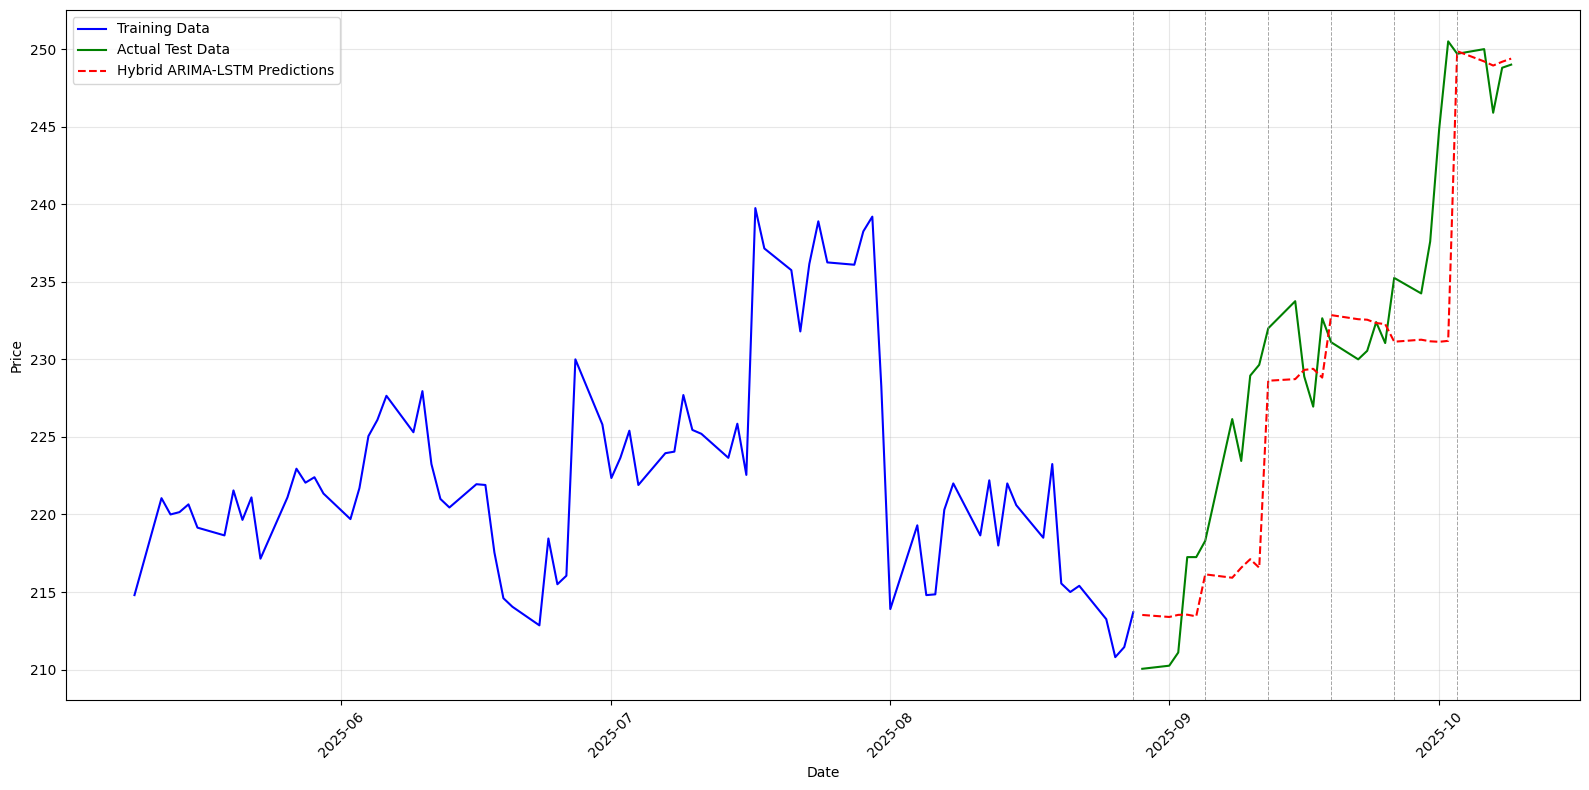

In [11]:
# ============================================
# 9. VISUALIZATION (UPDATED TO MATCH LSTM STYLE)
# ============================================

print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

# Determine date range for last 5 months (matching LSTM code)
end_date_plot = test_ts.index.max()
start_date_plot = end_date_plot - pd.DateOffset(months=5)

# Filter data for plotting (using DataFrame format to match LSTM code)
# Convert Series to DataFrame for consistency
train_data_plot = pd.DataFrame({'SU_Close': train_ts})
train_data_plot = train_data_plot[train_data_plot.index >= start_date_plot]

actual_test_data_plot = pd.DataFrame({'SU_Close': test_ts})
actual_test_data_plot = actual_test_data_plot[actual_test_data_plot.index >= start_date_plot]

predicted_data_plot = comparison_df[comparison_df.index >= start_date_plot]

# Create plot (matching LSTM style)
plt.figure(figsize=(16, 8))

# Plot training data (blue)
plt.plot(train_data_plot.index, train_data_plot['SU_Close'], 
         label='Training Data', color='blue', linewidth=1.5)

# Plot actual test data (green)
plt.plot(actual_test_data_plot.index, actual_test_data_plot['SU_Close'], 
         label='Actual Test Data', color='green', linewidth=1.5)

# Plot hybrid predictions (red dashed) - matching LSTM style
plt.plot(predicted_data_plot.index, predicted_data_plot['ARIMA_LSTM_Predicted'], 
         label='Hybrid ARIMA-LSTM Predictions', color='red', linestyle='--', linewidth=1.5)

# Add vertical line for train-test split (matching LSTM style)
plt.axvline(x=train_ts.index[-1], color='gray', 
            linestyle='--', linewidth=0.7, alpha=0.7)

# Add block boundaries (matching LSTM style)
for i in range(1, num_test_blocks):
    block_boundary = test_ts.index[i * forecast_horizon]
    plt.axvline(x=block_boundary, color='gray', linestyle='--', 
                alpha=0.7, linewidth=0.7)

plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# 10. FINAL SUMMARY
# ============================================

print(f"\n{'='*60}")
print("HYBRID ARIMA-LSTM FORECASTING COMPLETE")
print(f"{'='*60}")

print(f"\nModel Configuration:")
print(f"  ARIMA: ({p},{d},{q}) - from user input")
print(f"  LSTM (tuned on residuals): {lstm_units} units, dropout={dropout_rate}, seq_length={seq_length}")

print(f"\nForecasting Strategy:")
print(f"  - Recursive retraining with {forecast_horizon}-day blocks")
print(f"  - {num_test_blocks} blocks forecasted ({len(actuals)} days total)")
print(f"  - Hybrid = ARIMA_forecast + LSTM_residual_forecast")

print(f"\nARIMA Analysis:")
print(f"  - Model refitted for each of {num_test_blocks} blocks")
print(f"  - Coefficients and p-values tracked across all blocks")
print(f"  - Model statistics (AIC, BIC, Log Likelihood) available for each block")

print(f"\nHyperparameter Tuning:")
print(f"  - LSTM tuned with 80/20 hold-out validation on residuals")
print(f"  - Grid: {len(hyperparameter_grid['lstm_units'])}×{len(hyperparameter_grid['dropout_rate'])}×{len(hyperparameter_grid['seq_length'])} = {len(hyperparameter_grid['lstm_units']) * len(hyperparameter_grid['dropout_rate']) * len(hyperparameter_grid['seq_length'])} combinations")
print(f"  - Best validation RMSE: {best_val_rmse:.6f}")

print(f"\nForecasting Results:")
print(f"  Total forecast days: {len(actuals)}")
print(f"  RMSE: {rmse:.2f}")
print(f"  MAE:  {mae:.2f}")
print(f"  MAPE: {np.mean(np.abs((actuals - predictions) / actuals)) * 100:.2f}%")

print(f"\nOutput Files:")
print(f"  - arima_lstm.csv (hybrid predictions vs actuals)")
print(f"  - Can compare with arima.csv from ARIMA-only model")

print(f"\nKey Features:")
print(f"  1. ARIMA({p},{d},{q}) captures linear patterns using your previous parameters")
print(f"  2. ARIMA coefficients, statistics, and p-values printed for every block")
print(f"  3. LSTM specifically tuned on ARIMA residuals")
print(f"  4. Combined model leverages strengths of both approaches")
print(f"  5. Consistent with your ARIMA-only model for fair comparison")


HYBRID ARIMA-LSTM FORECASTING COMPLETE

Model Configuration:
  ARIMA: (2,1,4) - from user input
  LSTM (tuned on residuals): 64 units, dropout=0.5, seq_length=22

Forecasting Strategy:
  - Recursive retraining with 5-day blocks
  - 6 blocks forecasted (30 days total)
  - Hybrid = ARIMA_forecast + LSTM_residual_forecast

ARIMA Analysis:
  - Model refitted for each of 6 blocks
  - Coefficients and p-values tracked across all blocks
  - Model statistics (AIC, BIC, Log Likelihood) available for each block

Hyperparameter Tuning:
  - LSTM tuned with 80/20 hold-out validation on residuals
  - Grid: 2×2×3 = 12 combinations
  - Best validation RMSE: 0.072277

Forecasting Results:
  Total forecast days: 30
  RMSE: 6.42
  MAE:  4.49
  MAPE: 1.93%

Output Files:
  - arima_lstm.csv (hybrid predictions vs actuals)
  - Can compare with arima.csv from ARIMA-only model

Key Features:
  1. ARIMA(2,1,4) captures linear patterns using your previous parameters
  2. ARIMA coefficients, statistics, and p-v